In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [3]:
#data loading
df = pd.read_csv(r'C:\programming\mystery_dungeon_anal\simulation_results_2.csv')
df = df.sort_values('Spawn_Strategy')
df.shape

(920802, 12)

In [4]:
print(*df.columns, sep=": \n- ")

Seed: 
- Spawn_Strategy: 
- Initial_Drones_XY: 
- Goal_X: 
- Goal_Y: 
- Optimal_Tick: 
- Used_Tick: 
- Map_Coverage_%: 
- Spawn_Fail_Count: 
- Backtrack_Count: 
- Total_Spawned: 
- Success


In [5]:
i = 1
while(i <= 32):
    print(df[df['Spawn_Strategy']==i][['Used_Tick', 'Optimal_Tick', 'Map_Coverage_%']].describe())
    i*=2

           Used_Tick   Optimal_Tick  Map_Coverage_%
count  153467.000000  153467.000000   153467.000000
mean      169.859885     168.859885       49.372748
std       108.966419     108.966419       28.429590
min         2.000000       1.000000        0.290000
25%        84.000000      83.000000       25.680000
50%       159.000000     158.000000       48.050000
75%       242.000000     241.000000       73.240000
max       566.000000     565.000000       99.900000
           Used_Tick   Optimal_Tick  Map_Coverage_%
count  153467.000000  153467.000000   153467.000000
mean      107.038425     106.038425       50.686564
std        78.346218      78.346218       29.217677
min         2.000000       1.000000        0.680000
25%        46.000000      45.000000       26.270000
50%        93.000000      92.000000       51.170000
75%       147.000000     146.000000       77.340000
max       450.000000     449.000000      100.000000
           Used_Tick   Optimal_Tick  Map_Coverage_%
count  15346

In [6]:
import pandas as pd

df = pd.read_csv(r'C:\programming\mystery_dungeon_anal\simulation_results_2.csv')
df = df.drop_duplicates(subset=['Seed', 'Spawn_Strategy'], keep='first')
df['Waste_Tick'] = df['Used_Tick'] - df['Optimal_Tick']

# 그룹(드론 대수)별로 Waste_Tick의 모든 통계량을 한눈에 출력
eda_summary = df.groupby('Spawn_Strategy')['Waste_Tick'].describe()
print(eda_summary)


                count       mean        std  min  25%  50%  75%    max
Spawn_Strategy                                                        
1               571.0   1.000000   0.000000  1.0  1.0  1.0  1.0    1.0
2               571.0   1.000000   0.000000  1.0  1.0  1.0  1.0    1.0
4               571.0   1.000000   0.000000  1.0  1.0  1.0  1.0    1.0
8               571.0   1.052539   0.683674  1.0  1.0  1.0  1.0   13.0
16              571.0   5.189142  13.910716  1.0  1.0  1.0  3.0  179.0
32              571.0  10.642732  25.649976  1.0  1.0  1.0  9.0  339.0


In [7]:
# 성공 여부만 탐색
df = df[df["Success"]==True]

C:\Users\user\AppData\Local\Temp\ipykernel_33436\3205040075.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spawn_Strategy', y='Used_Tick', palette='Blues')


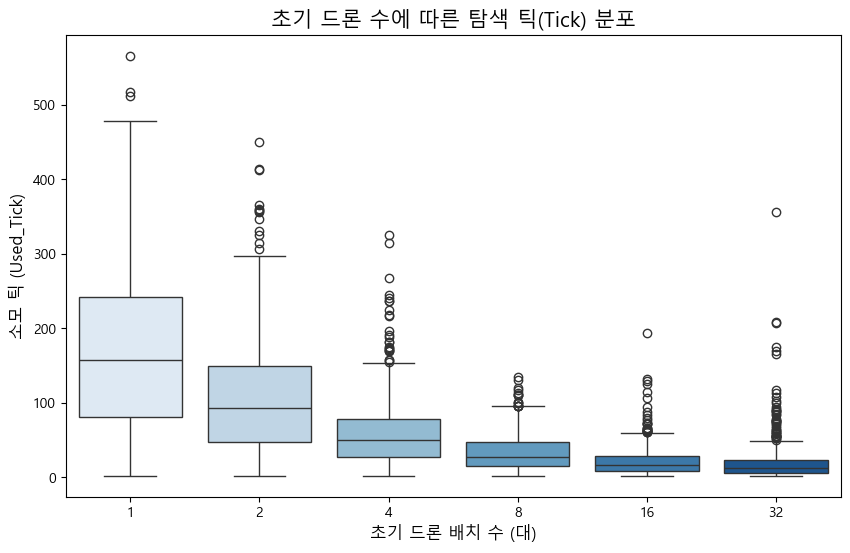

[1단계 ANOVA 검정] P-value: 0.00000

결론: 초기 드론 배치 수에 따라 탐색 성능에 유의미한 차이가 존재합니다.

[2단계 Tukey HSD 사후 검정 표]
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
     1      2  -60.6112    0.0  -70.9398  -50.2826   True
     1      4 -110.4676    0.0 -120.7962  -100.139   True
     1      8 -135.2434    0.0 -145.5721 -124.9148   True
     1     16 -147.5324    0.0  -157.861 -137.2038   True
     1     32 -148.7618    0.0 -159.0905 -138.4332   True
     2      4  -49.8564    0.0   -60.185  -39.5278   True
     2      8  -74.6322    0.0  -84.9609  -64.3036   True
     2     16  -86.9212    0.0  -97.2498  -76.5926   True
     2     32  -88.1506    0.0  -98.4792   -77.822   True
     4      8  -24.7758    0.0  -35.1045  -14.4472   True
     4     16  -37.0648    0.0  -47.3934  -26.7362   True
     4     32  -38.2942    0.0  -48.6228  -27.9656   True
     8     16   -12.289 0.0091

In [8]:
#box plot
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(data=df, x='Spawn_Strategy', y='Used_Tick', palette='Blues')
plt.title('초기 드론 수에 따른 탐색 틱(Tick) 분포', fontsize=15)
plt.xlabel('초기 드론 배치 수 (대)', fontsize=12)
plt.ylabel('소모 틱 (Used_Tick)', fontsize=12)
plt.show()

# ---------------------------------------------------------
# 3. 분산 분석 (ANOVA) 및 사후 검정
# ---------------------------------------------------------
groups = [group['Used_Tick'].values for name, group in df.groupby('Spawn_Strategy')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"[1단계 ANOVA 검정] P-value: {p_value:.5f}\n")

if p_value < 0.05:
    print("결론: 초기 드론 배치 수에 따라 탐색 성능에 유의미한 차이가 존재합니다.\n")
    print("="*50)
    print("[2단계 Tukey HSD 사후 검정 표]")
    print("="*50)
    
    # 튜키 검정 실행
    tukey_result = pairwise_tukeyhsd(endog=df['Used_Tick'], 
                                     groups=df['Spawn_Strategy'], 
                                     alpha=0.05)
    print(tukey_result)
else:
    print("결론: 통계적으로 유의미한 성능 차이가 발견되지 않았습니다.")

In [9]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 이번에는 타겟 변수를 순수 낭비 틱이 아닌 '전체 소모 틱(Used_Tick)'으로 설정합니다.
model_raw = ols('Used_Tick ~ C(Spawn_Strategy)', data=df).fit()

print("="*60)
print("[날것의 데이터 (Used_Tick) 기준 OLS 회귀 분석 요약표]")
print("="*60)
print(model_raw.summary())

[날것의 데이터 (Used_Tick) 기준 OLS 회귀 분석 요약표]
                            OLS Regression Results                            
Dep. Variable:              Used_Tick   R-squared:                       0.439
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     534.7
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:08:46   Log-Likelihood:                -18954.
No. Observations:                3426   AIC:                         3.792e+04
Df Residuals:                    3420   BIC:                         3.796e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

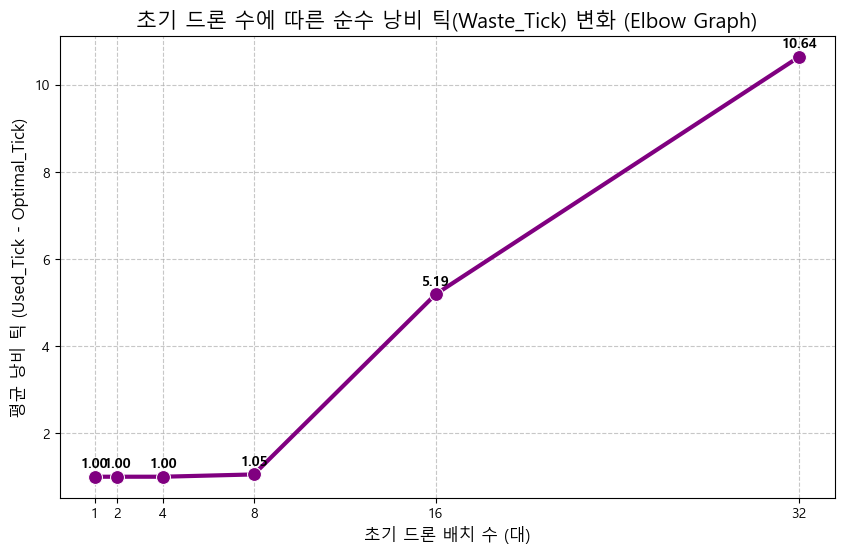

[Waste_Tick ANOVA 검정] P-value: 0.00000

[Waste_Tick 기준 Tukey HSD 사후 검정 표]
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     1      2      0.0   1.0 -2.0108  2.0108  False
     1      4      0.0   1.0 -2.0108  2.0108  False
     1      8   0.0525   1.0 -1.9582  2.0633  False
     1     16   4.1891   0.0  2.1784  6.1999   True
     1     32   9.6427   0.0   7.632 11.6535   True
     2      4      0.0   1.0 -2.0108  2.0108  False
     2      8   0.0525   1.0 -1.9582  2.0633  False
     2     16   4.1891   0.0  2.1784  6.1999   True
     2     32   9.6427   0.0   7.632 11.6535   True
     4      8   0.0525   1.0 -1.9582  2.0633  False
     4     16   4.1891   0.0  2.1784  6.1999   True
     4     32   9.6427   0.0   7.632 11.6535   True
     8     16   4.1366   0.0  2.1258  6.1474   True
     8     32   9.5902   0.0  7.5794  11.601   True
    16     32   5.4536   0.0  3.4428  7.46

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. 데이터 불러오기 및 전처리
df = pd.read_csv(r'C:\programming\mystery_dungeon_anal\simulation_results_2.csv')
df = df.drop_duplicates(subset=['Seed', 'Spawn_Strategy'], keep='first') # 중복 제거
df = df.sort_values('Spawn_Strategy')

# 2. 새로운 궁극의 지표 생성: 순수 낭비 틱 (허비한 시간)
df['Waste_Tick'] = df['Used_Tick'] - df['Optimal_Tick']

# 3. 그룹별 평균 계산 (그래프용)
mean_waste = df.groupby('Spawn_Strategy')['Waste_Tick'].mean().reset_index()

# 4. 엘보우(Elbow) 그래프 시각화
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'Malgun Gothic' # 맥은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 꺾은선 그래프
sns.lineplot(data=mean_waste, x='Spawn_Strategy', y='Waste_Tick', 
             marker='o', markersize=10, linewidth=3, color='purple')

# 각 점에 실제 값(평균 낭비 틱) 텍스트 추가
for i in range(mean_waste.shape[0]):
    plt.text(mean_waste['Spawn_Strategy'].iloc[i], 
             mean_waste['Waste_Tick'].iloc[i] + (mean_waste['Waste_Tick'].max()*0.02), 
             f"{mean_waste['Waste_Tick'].iloc[i]:.2f}", 
             horizontalalignment='center', size='medium', color='black', weight='semibold')

plt.title('초기 드론 수에 따른 순수 낭비 틱(Waste_Tick) 변화 (Elbow Graph)', fontsize=15)
plt.xlabel('초기 드론 배치 수 (대)', fontsize=12)
plt.ylabel('평균 낭비 틱 (Used_Tick - Optimal_Tick)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([1, 2, 4, 8, 16, 32]) # x축 눈금 고정
plt.show()

# ---------------------------------------------------------
# 5. 분산 분석 (ANOVA) 및 사후 검정 (타겟: Waste_Tick)
# ---------------------------------------------------------
groups = [group['Waste_Tick'].values for name, group in df.groupby('Spawn_Strategy')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"[Waste_Tick ANOVA 검정] P-value: {p_value:.5f}\n")

if p_value < 0.05:
    print("="*55)
    print("[Waste_Tick 기준 Tukey HSD 사후 검정 표]")
    print("="*55)
    tukey_result = pairwise_tukeyhsd(endog=df['Waste_Tick'], 
                                     groups=df['Spawn_Strategy'], 
                                     alpha=0.05)
    print(tukey_result)

C:\Users\user\AppData\Local\Temp\ipykernel_33436\4203380457.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spawn_Strategy', y='Waste_Tick', palette='Purples')


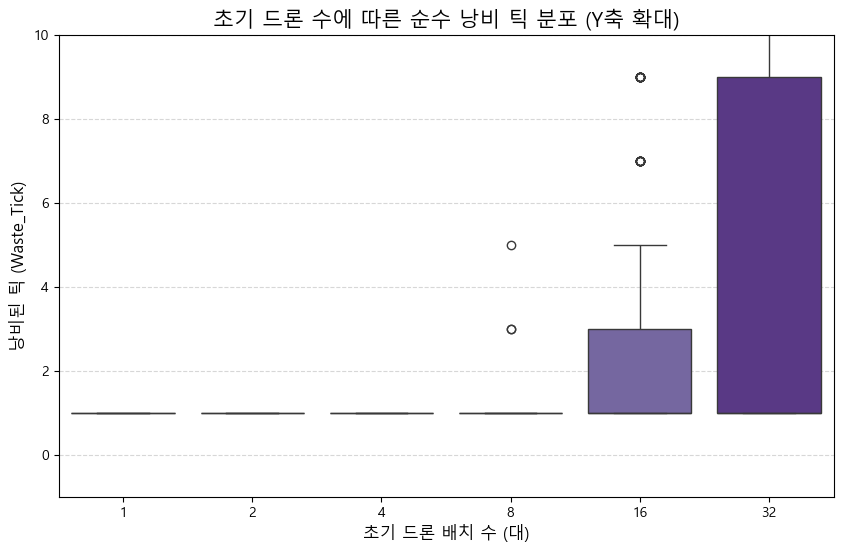

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 불러오기 및 지표 생성
df = pd.read_csv(r'C:\programming\mystery_dungeon_anal\simulation_results_2.csv')
df = df.drop_duplicates(subset=['Seed', 'Spawn_Strategy'], keep='first')
df['Waste_Tick'] = df['Used_Tick'] - df['Optimal_Tick']

# 2. 박스 플롯 시각화 세팅
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'Malgun Gothic' # 맥은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 박스 플롯 그리기
sns.boxplot(data=df, x='Spawn_Strategy', y='Waste_Tick', palette='Purples')

# 3. 핵심: Y축 줌인 (상자가 뭉개지지 않도록 범위 제한)
# 데이터 상황에 맞춰 상한선(10)을 20이나 50으로 조절하셔도 됩니다.
plt.ylim(-1, 10) 

plt.title('초기 드론 수에 따른 순수 낭비 틱 분포 (Y축 확대)', fontsize=15)
plt.xlabel('초기 드론 배치 수 (대)', fontsize=12)
plt.ylabel('낭비된 틱 (Waste_Tick)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

In [12]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. 모델 피팅 (이미 하셨던 코드와 동일)
model = ols('Waste_Tick ~ C(Spawn_Strategy)', data=df).fit()

# 2. 종합 요약표 출력
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Waste_Tick   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     63.06
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           4.22e-63
Time:                        12:08:50   Log-Likelihood:                -13347.
No. Observations:                3426   AIC:                         2.671e+04
Df Residuals:                    3420   BIC:                         2.674e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [16]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Goal X, Y 좌표를 묶어서 고유한 '맵 ID' 생성 (Block 변수)
df['Map_ID'] = df['Goal_X'].astype(str) + "_" + df['Goal_Y'].astype(str)

print("=== [강건성 검정] 동일 지형(Map_ID) 통제 이원분산분석 ===")

# 주의: Map_ID의 종류(고유값)가 너무 많으면 메모리 에러가 날 수 있습니다.
# 만약 에러가 난다면 데이터가 가장 많은 특정 Map_ID 상위 10개만 필터링해서 돌려보는 것을 권장합니다.

# Waste_Tick에 대한 이원분산분석 (Map_ID라는 지형 난이도를 통제)
model_blocked = ols('Used_Tick ~ C(Spawn_Strategy) + C(Map_ID)', data=df).fit()
anova_blocked = sm.stats.anova_lm(model_blocked, typ=2)

print(anova_blocked)
print("\n* 지형을 통제한 후의 설명력 (R-squared):", round(model_blocked.rsquared, 4))

print(model_blocked.summary())

=== [강건성 검정] 동일 지형(Map_ID) 통제 이원분산분석 ===
                         sum_sq      df           F        PR(>F)
C(Spawn_Strategy)  1.001456e+07     5.0  562.720155  0.000000e+00
C(Map_ID)          2.248090e+06   452.0    1.397352  4.875259e-07
Residual           1.056412e+07  2968.0         NaN           NaN

* 지형을 통제한 후의 설명력 (R-squared): 0.5372
                            OLS Regression Results                            
Dep. Variable:              Used_Tick   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     7.539
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          7.18e-269
Time:                        12:35:05   Log-Likelihood:                -18623.
No. Observations:                3426   AIC:                         3.816e+04
Df Residuals:                    2968   BIC:                         4.097e+04
Df Model:                